# Customer Analytics — Level 4: Customer Lifetime Value (CLV)

After understanding customer acquisition, retention, and purchasing behavior in the previous analyses, the next question is:

**Which customers create the greatest long-term value for the business?**

Customer Lifetime Value (CLV) helps quantify the economic contribution of each customer by measuring the total revenue generated throughout the observed period. Identifying high-value customers allows businesses to prioritize retention efforts, personalize engagement strategies, and allocate resources more effectively.

This notebook uses the cleaned Online Retail dataset and focuses on **Historical CLV**, meaning the analysis is based on actual customer transactions rather than future-value predictions.

> Note: Because the original dataset does not contain product cost information, profit is estimated using the simulated margin assumptions established in Level 1. Revenue remains the primary CLV metric, while profit is included as a complementary perspective.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

np.random.seed(42)

sns.set_theme(style="whitegrid", palette="deep")
sns.set_context("talk")

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
pd.set_option('display.max_columns', None)

df = pd.read_csv("data//raw/online_retail_clean.csv", parse_dates=["InvoiceDate"])
print(f"Total transaksi : {len(df):,}")
print(f"Total customers  : {df['CustomerID'].nunique():,}")

Total transaksi : 397,884
Total customers  : 4,338


## 1. Customer Lifetime Value Calculation

The first step is to calculate the historical value generated by each customer.

For every customer, we aggregate all transactions across the observation period and compute:

- Total Revenue
- Total Profit (estimated)
- Number of Orders
- Active Duration

This creates a customer-level view that allows us to compare economic contribution across the entire customer base.

In [2]:
clv = df.groupby("CustomerID").agg(
    Revenue=("Revenue", "sum"),
    Profit=("Profit", "sum"),
    NumOrders=("InvoiceNo", "nunique"),
    FirstPurchase=("InvoiceDate", "min"),
    LastPurchase=("InvoiceDate", "max"),
    Country=("Country", "first")
).reset_index()

clv["AvgOrderValue"] = clv["Revenue"] / clv["NumOrders"]
clv["CustomerLifespanDays"] = (clv["LastPurchase"] - clv["FirstPurchase"]).dt.days

clv = clv.sort_values("Revenue", ascending=False).reset_index(drop=True)
clv["Rank"] = clv.index + 1

print("Summary CLV (Revenue):")
print(clv["Revenue"].describe().round(2))
print(f"\nAverage CLV per customer : £{clv['Revenue'].mean():,.2f}")
print(f"Median CLV per customer   : £{clv['Revenue'].median():,.2f}")
clv.head()

Summary CLV (Revenue):
count     4,338.00
mean      2,054.27
std       8,989.23
min           3.75
25%         307.41
50%         674.48
75%       1,661.74
max     280,206.02
Name: Revenue, dtype: float64

Average CLV per customer : £2,054.27
Median CLV per customer   : £674.49


,CustomerID,Revenue,Profit,NumOrders,FirstPurchase,LastPurchase,Country,AvgOrderValue,CustomerLifespanDays,Rank
0,14646,"280,206.02","118,350.12",73,2010-12-20 10:09:00,2011-12-08 12:12:00,Netherlands,"3,838.44",353,1
1,18102,"259,657.30","109,190.95",60,2010-12-07 16:42:00,2011-12-09 11:50:00,United Kingdom,"4,327.62",366,2
2,17450,"194,550.79","81,339.18",46,2010-12-07 09:23:00,2011-12-01 13:29:00,United Kingdom,"4,229.36",359,3
3,16446,"168,472.50","57,955.84",2,2011-05-18 09:52:00,2011-12-09 09:15:00,United Kingdom,"84,236.25",204,4
4,14911,"143,825.06","61,086.86",201,2010-12-01 14:05:00,2011-12-08 15:54:00,EIRE,715.55,372,5


## 2. Identifying High-Value Customers

Not all customers contribute equally to business performance.

In this section, customers are ranked based on their total lifetime revenue. The objective is to identify the individuals who generate the highest economic value and understand how concentrated customer value is within the business.

This ranking provides a practical foundation for VIP programs, account management strategies, and retention initiatives focused on high-value customers.

In [3]:
top20 = clv.head(20)[["Rank","CustomerID","Revenue","Profit","NumOrders","AvgOrderValue","Country"]]
top20

,Rank,CustomerID,Revenue,Profit,NumOrders,AvgOrderValue,Country
0,1,14646,"280,206.02","118,350.12",73,"3,838.44",Netherlands
1,2,18102,"259,657.30","109,190.95",60,"4,327.62",United Kingdom
2,3,17450,"194,550.79","81,339.18",46,"4,229.36",United Kingdom
3,4,16446,"168,472.50","57,955.84",2,"84,236.25",United Kingdom
4,5,14911,"143,825.06","61,086.86",201,715.55,EIRE
5,6,12415,"124,914.53","52,620.69",21,"5,948.31",Australia
6,7,14156,"117,379.63","49,968.92",55,"2,134.18",EIRE
7,8,17511,"91,062.38","39,142.83",31,"2,937.50",United Kingdom
8,9,16029,"81,024.84","34,398.01",63,"1,286.11",United Kingdom
9,10,12346,"77,183.60","35,414.32",1,"77,183.60",United Kingdom


### Visualizing the Top Revenue-Generating Customers

The chart below highlights the twenty customers with the highest lifetime revenue contribution.

Comparing these customers reveals the scale of value differences within the customer base and helps determine whether revenue is broadly distributed or concentrated among a small group of customers.

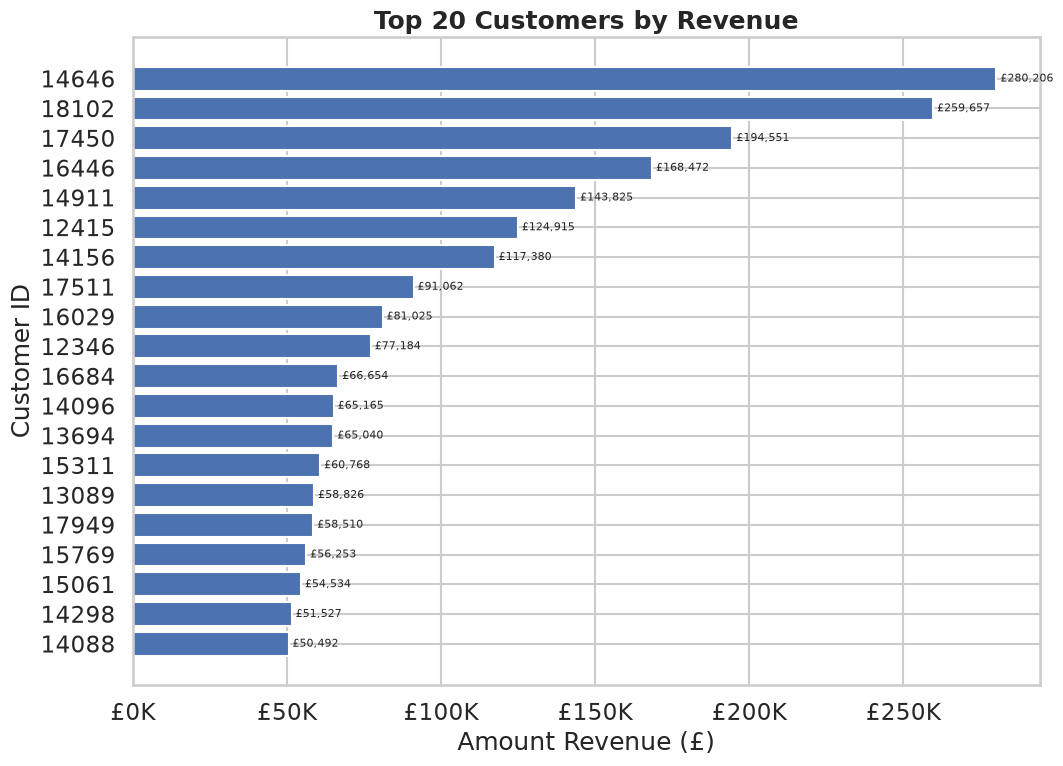

20 Top customers contribute 23.9% from total revenue (drom 4,338 total customer).


In [4]:
fig, ax = plt.subplots(figsize=(11, 8))
top20_sorted = top20.sort_values("Revenue")
bars = ax.barh(top20_sorted["CustomerID"].astype(str), top20_sorted["Revenue"], color="#4C72B0")
ax.set_title("Top 20 Customers by Revenue")
ax.set_xlabel("Amount Revenue (£)")
ax.set_ylabel("Customer ID")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x/1000:.0f}K"))
for b in bars:
    ax.text(b.get_width(), b.get_y()+b.get_height()/2, f" £{b.get_width():,.0f}", va='center', fontsize=8)
plt.tight_layout()
plt.savefig("pictures/level4_top20_customers.png", dpi=120, bbox_inches='tight')
plt.show()

total_rev = clv["Revenue"].sum()
top20_rev_pct = top20["Revenue"].sum() / total_rev * 100
print(f"20 Top customers contribute {top20_rev_pct:.1f}% from total revenue (drom {len(clv):,} total customer).")

## 3. CLV Distribution Analysis

Average customer value often hides substantial variation across the customer base.

To better understand customer economics, we examine the distribution of lifetime revenue. This analysis helps reveal whether value is evenly distributed or dominated by a relatively small number of high-spending customers.

A strongly right-skewed distribution would indicate that most customers generate modest value, while a small segment contributes disproportionately large amounts of revenue.

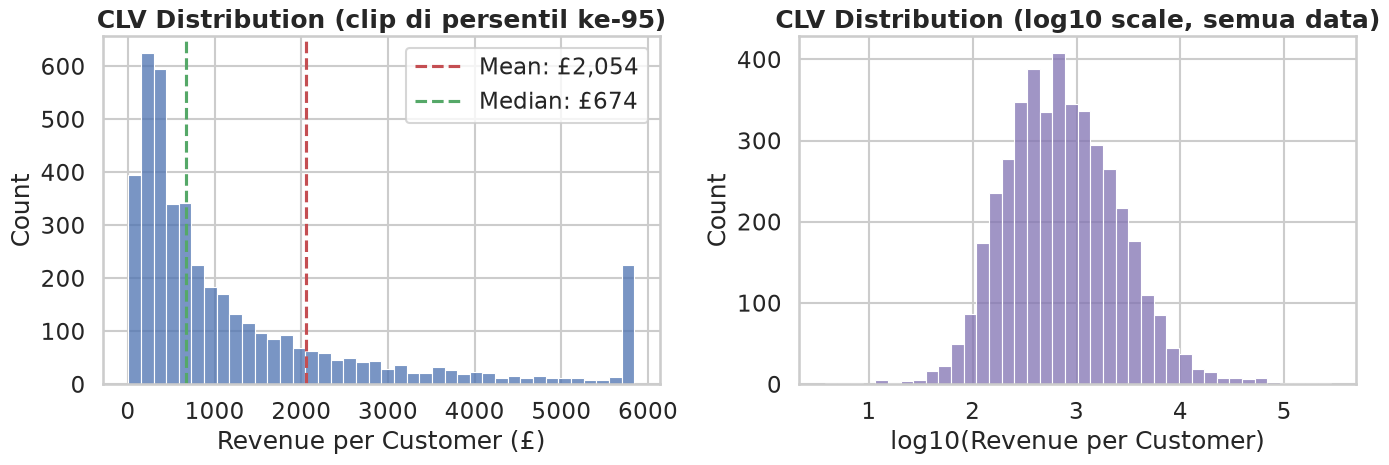

Skewness: 19.32 (>1 = sangat right-skewed)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normal Histogram (clipped so it can be read, because there's an extreme outlier of £280K)
clipped = clv["Revenue"].clip(upper=clv["Revenue"].quantile(0.95))
sns.histplot(clipped, bins=40, color="#4C72B0", ax=axes[0])
axes[0].axvline(clv["Revenue"].mean(), color="#C44E52", linestyle="--", label=f"Mean: £{clv['Revenue'].mean():,.0f}")
axes[0].axvline(clv["Revenue"].median(), color="#55A868", linestyle="--", label=f"Median: £{clv['Revenue'].median():,.0f}")
axes[0].set_title("CLV Distribution (clip di persentil ke-95)")
axes[0].set_xlabel("Revenue per Customer (£)")
axes[0].legend()

# Log scale to see the original shape of the distribution (including outliers)
sns.histplot(np.log10(clv["Revenue"].clip(lower=1)), bins=40, color="#8172B2", ax=axes[1])
axes[1].set_title("CLV Distribution (log10 scale, semua data)")
axes[1].set_xlabel("log10(Revenue per Customer)")

plt.tight_layout()
plt.savefig("pictures/level4_clv_distribution.png", dpi=120, bbox_inches='tight')
plt.show()

print(f"Skewness: {clv['Revenue'].skew():.2f} (>1 = sangat right-skewed)")

## 4. Revenue Concentration and Pareto Analysis

Customer value is rarely distributed evenly.

A common business pattern is the Pareto Principle, often referred to as the 80/20 rule, where a relatively small percentage of customers generates a large percentage of total revenue.

This analysis evaluates the concentration of revenue across customers and measures how closely the business follows that pattern.

In [6]:
clv_sorted = clv.sort_values("Revenue", ascending=False).reset_index(drop=True)
clv_sorted["Rank"] = clv_sorted.index + 1
clv_sorted["CumulativeRevenue"] = clv_sorted["Revenue"].cumsum()
clv_sorted["CumulativeRevenuePct"] = clv_sorted["CumulativeRevenue"] / clv_sorted["Revenue"].sum() * 100
clv_sorted["CustomerPct"] = clv_sorted["Rank"] / len(clv_sorted) * 100

# Insight: top 20% customer contributing how much % of revenue?
top20_cutoff = int(len(clv_sorted) * 0.2)
pct_revenue_top20 = clv_sorted.iloc[:top20_cutoff]["Revenue"].sum() / clv_sorted["Revenue"].sum() * 100

# What % of customers are needed to hit 80% of the revenue?
idx_80 = (clv_sorted["CumulativeRevenuePct"] >= 80).idxmax()
pct_customer_for_80pct_revenue = clv_sorted.loc[idx_80, "CustomerPct"]

print(f"Top 20% customer ({top20_cutoff:,} people) produce {pct_revenue_top20:.1f}% revenue")
print(f"{pct_customer_for_80pct_revenue:.1f}% customer produce 80% of revenue")

Top 20% customer (867 people) produce 74.6% revenue
26.1% customer produce 80% of revenue


### Visualizing Revenue Concentration

The Pareto chart ranks customers from highest to lowest revenue contribution and tracks cumulative revenue share.

This visualization helps identify how much of total revenue is generated by the most valuable customers and provides a clear view of customer concentration risk.

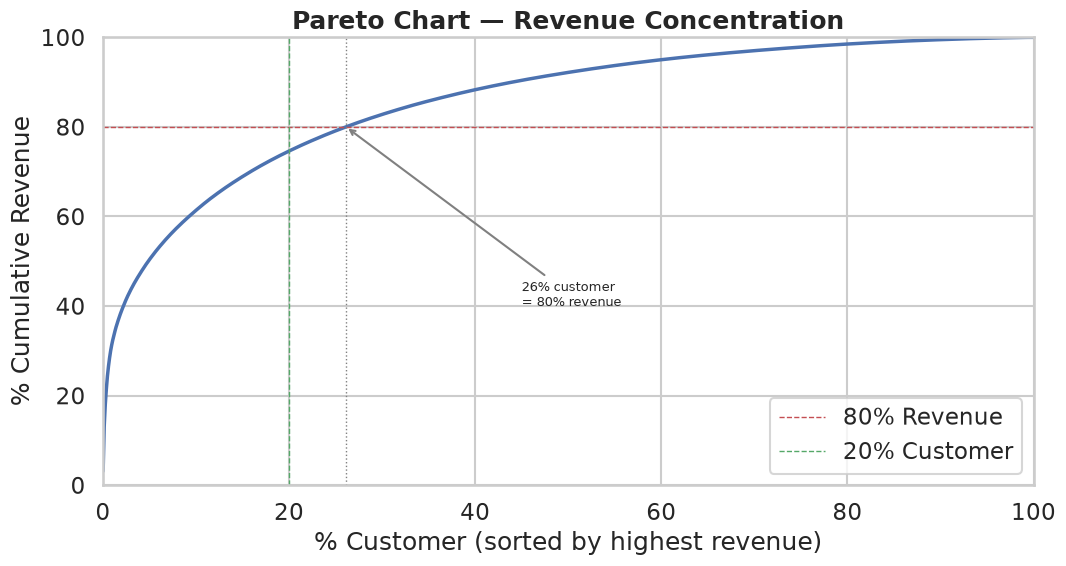

In [7]:
fig, ax1 = plt.subplots(figsize=(11, 6))

sample = clv_sorted.iloc[::5]  # sampling so the lines are smooth & the render is light

ax1.plot(sample["CustomerPct"], sample["CumulativeRevenuePct"], color="#4C72B0", linewidth=2.5)
ax1.axhline(80, color="#C44E52", linestyle="--", linewidth=1, label="80% Revenue")
ax1.axvline(20, color="#55A868", linestyle="--", linewidth=1, label="20% Customer")
ax1.axvline(pct_customer_for_80pct_revenue, color="grey", linestyle=":", linewidth=1)

ax1.set_xlabel("% Customer (sorted by highest revenue)")
ax1.set_ylabel("% Cumulative Revenue")
ax1.set_title("Pareto Chart — Revenue Concentration")
ax1.set_xlim(0, 100)
ax1.set_ylim(0, 100)
ax1.legend(loc="lower right")

ax1.annotate(f"{pct_customer_for_80pct_revenue:.0f}% customer\n= 80% revenue",
             xy=(pct_customer_for_80pct_revenue, 80), xytext=(45, 40),
             arrowprops=dict(arrowstyle="->", color="grey"), fontsize=9)

plt.tight_layout()
plt.savefig("pictures/level4_pareto_chart.png", dpi=120, bbox_inches='tight')
plt.show()

## 5. Executive Summary

Customer Lifetime Value analysis provides a clearer picture of how customer value is distributed across the business.

The results reveal the extent to which revenue is concentrated among high-value customers and whether business performance depends on a relatively small group of customers or a broader customer base.

The ranking analysis identifies the customers generating the greatest lifetime value, while the distribution analysis highlights the variation in spending behavior across the population. Finally, the Pareto analysis quantifies revenue concentration and evaluates the importance of top-performing customers.

These findings are particularly valuable for customer retention and growth strategies. High-value customers may warrant dedicated retention efforts, while lower-value segments may require different engagement approaches.

The next stage of the Customer Analytics framework will focus on customer segmentation through RFM Analysis, enabling customers to be grouped based on Recency, Frequency, and Monetary behavior.